# NBA Game Winner Predictor: Predictive Machine Learning Pipeline

**Project Overview:**
This notebook demonstrates a machine learning workflow to predict NBA game outcomes (`WIN`/`LOSS`). It starts from high-accuracy baseline models built on data leakage, then progresses to a predictive rolling pipeline, and finally arriving at a champion model utilizing comparative matchup differentials.

# Phase 1: Diagnostic Leakage Baseline
This initial phase serves as an intentional test configuration where the model is trained using final in-game stats, that it would never actually have access to before a game starts. I use this phase as a diagnostic benchmark to ensure my data pipeline functions correctly and to establish an theoretical upper bound for accuracy before I enforce true chronological boundaries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nba_api.stats.static import teams
from nba_api.stats.endpoints import leaguegamefinder
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import time

In [2]:
nba_teams = teams.get_teams()

In [3]:
team_abbr_to_id = {team["abbreviation"]: team["id"] for team in nba_teams}
all_games = pd.DataFrame()

for team in nba_teams:
    team_id = team["id"]
    gamefinder = leaguegamefinder.LeagueGameFinder(
        team_id_nullable=team_id, season_type_nullable="Regular Season"
    )
    games = gamefinder.get_data_frames()[0]
    all_games = pd.concat([all_games, games], ignore_index=True)
    time.sleep(2.5)

## 1.1: Data Ingestion & Boundary Scoping
In this initial data harvesting stage, raw game records are retrieved from the official NBA statistics endpoints. I establish temporal boundaries by filtering out non-regular season data and decided to focus my scope to modern tactical eras to ensure features represent current gameplay dynamics.

In [4]:
games_modern = all_games[
    (all_games.SEASON_ID.str[-4:] == "2019")
    | (all_games.SEASON_ID.str[-4:] == "2020")
    | (all_games.SEASON_ID.str[-4:] == "2021")
    | (all_games.SEASON_ID.str[-4:] == "2022")
    | (all_games.SEASON_ID.str[-4:] == "2023")
    | (all_games.SEASON_ID.str[-4:] == "2024")
]

## 1.2: Data Cleaning & Formatting
I chronologically sort the data to safely maintain chronological order, handle missing feature identities, map explicit game-by-game opponent connections, and correct column text formatting.

In [5]:
# Convert GAME_DATE to pandas datetime
games_modern["GAME_DATE"] = pd.to_datetime(games_modern["GAME_DATE"])
games_modern.sort_values(by="GAME_DATE", inplace=True)

# Add binary "WIN" column, remove categorical WL column
games_modern["WIN"] = games_modern["WL"].apply(lambda x: 1 if x == "W" else 0)

# Convert int stat columns to float type for accurate data analysis
games_modern["MIN"] = games_modern["MIN"].astype(float)  # minutes
games_modern["PTS"] = games_modern["PTS"].astype(float)  # points
games_modern["FGM"] = games_modern["FGM"].astype(float)  # field goals made
games_modern["FGA"] = games_modern["FGA"].astype(float)  # field goals attempted
games_modern["FG3M"] = games_modern["FG3M"].astype(float)  # 3s made
games_modern["FG3A"] = games_modern["FG3A"].astype(float)  # 3s attempted
games_modern["FTM"] = games_modern["FTM"].astype(float)  # free throws made
games_modern["FTA"] = games_modern["FTA"].astype(float)  # free throws attempted
games_modern["REB"] = games_modern["REB"].astype(float)  # rebounds
games_modern["OREB"] = games_modern["OREB"].astype(float)  # offensive rebounds
games_modern["DREB"] = games_modern["DREB"].astype(float)  # defensive rebounds
games_modern["AST"] = games_modern["AST"].astype(float)  # assists
games_modern["BLK"] = games_modern["BLK"].astype(float)  # blocks
games_modern["TOV"] = games_modern["TOV"].astype(float)  # turnovers
games_modern["PF"] = games_modern["PF"].astype(float)  # personal fouls

def get_opponent_id(matchup, team_abbr_to_id, team_id):
    if "@" in matchup:
        opponent_abbr = matchup.split(" @ ")[-1]
    else:
        opponent_abbr = matchup.split(" vs. ")[-1]
    return team_abbr_to_id.get(opponent_abbr, team_id)


games_modern["OPP_TEAM_ID"] = games_modern.apply(
    lambda row: get_opponent_id(row["MATCHUP"], team_abbr_to_id, row["TEAM_ID"]), axis=1
)

## 1.3: Baseline Feature Engineering (Advanced Metrics)
I understand that raw data do not effectively reveal operational performance. Therefore, I transform raw box score inputs into classic efficiency metrics, such as True Shooting and Effective Field Goal percentages, to provide the estimators with baseline measures of possession efficiency.

1. Effective Field Goal Percentage (`EFG%`): Evaluates true shooting productivity by adjusting for the added value of the 3-point shot.
2. Turnover Percentage (`TOV%`): Standardizes turnover rates per 100 team possessions.
3. Free Throw Attempt Rate (`FTR`): Tracks physical aggression and drawing fouls.
4. True Shooting Percentage (`TS%`): A comprehensive efficiency metric factoring in field goals, 3-pointers, and free throws.

In [6]:
# Define 'HGA' (Home Game Advantage)
games_modern["HGA"] = games_modern["MATCHUP"].apply(lambda x: 0 if "@" in x else 1)

# Define 'Last Game Outcome'
games_modern["LAST_GAME_OUTCOME"] = (
    games_modern.groupby("TEAM_ID")["WIN"].shift(1).fillna(0)
)

# Define 'EFG%' (Effective Field Goal Percentage)
games_modern["EFG%"] = (
    games_modern["FGM"] + (0.5 * games_modern["FG3M"])
) / games_modern["FGA"]

# Define 'TOV%' (Turnover Percentage)
games_modern["TOV%"] = games_modern["TOV"] / (
    games_modern["FGA"] + 0.44 * games_modern["FTA"] + games_modern["TOV"]
)

# Define 'FTR' (Free Throw Attempt Rate)
games_modern["FTR"] = games_modern["FTA"] / games_modern["FGA"]

# Define 'TS%' (True Shooting Percentage)
games_modern["TS%"] = games_modern["PTS"] / (
    2 * (games_modern["FGA"] + (0.44 * games_modern["FTA"]))
)

In [7]:
le = LabelEncoder()
games_modern["TEAM_ID"] = le.fit_transform(games_modern["TEAM_ID"])
games_modern["OPP_TEAM_ID"] = le.fit_transform(games_modern["OPP_TEAM_ID"])
games_modern["GAME_ID"] = le.fit_transform(games_modern["GAME_ID"])

In [8]:
features = [
    "TEAM_ID",
    "OPP_TEAM_ID",
    "PTS",
    "OREB",
    "DREB",
    "REB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "EFG%",
    "TOV%",
    "FTR",
    "TS%",
    "HGA",
    "LAST_GAME_OUTCOME",
]
X = games_modern[features]
y = games_modern[["WIN"]].values.ravel()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 1.4: Diagnostic Baseline Architecture Overview
To establish my diagnostic baseline, I evaluate four distinct algorithmic architectures across varying distance, linear, and tree-based paradigms:

They are: K-Nearest Neighbors(KNN), Logistic Regression, Decision Tree Classifier, Random Forest Classifier

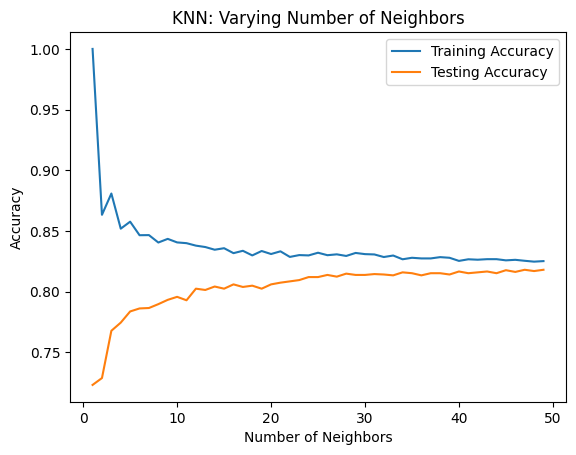

Confusion Matrix:
[[1179  252]
 [ 262 1131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1431
           1       0.82      0.81      0.81      1393

    accuracy                           0.82      2824
   macro avg       0.82      0.82      0.82      2824
weighted avg       0.82      0.82      0.82      2824



In [10]:
# Model 1: K Neighbors Classifier

neighbors = np.arange(1,50)
train_accuracies = {}
test_accuracies = {}
for neighbor in neighbors:
    knn = KNeighborsClassifier(n_neighbors = neighbor)
    knn.fit(X_train_scaled, y_train)
    train_accuracies[neighbor] = knn.score(X_train_scaled, y_train)
    test_accuracies[neighbor] = knn.score(X_test_scaled, y_test)

plt.title("KNN: Varying Number of Neighbors")

plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")
plt.plot(neighbors,test_accuracies.values(), label="Testing Accuracy")

plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

plt.show()

knn_peak = KNeighborsClassifier(n_neighbors = 47)
knn_peak.fit(X_train_scaled, y_train)
y_pred_knn = knn_peak.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


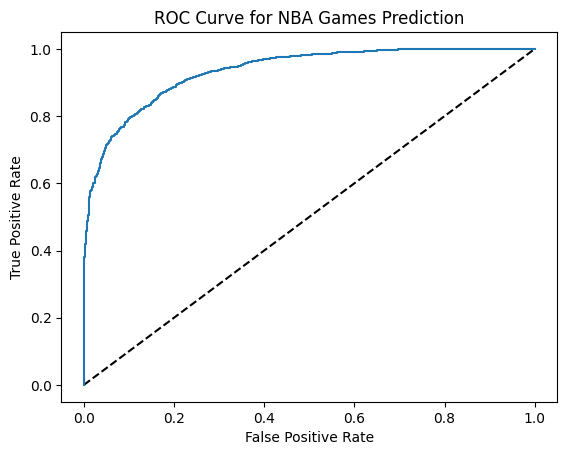

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1431
           1       0.84      0.85      0.84      1393

    accuracy                           0.85      2824
   macro avg       0.85      0.85      0.85      2824
weighted avg       0.85      0.85      0.85      2824

Ridge Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1431
           1       0.84      0.85      0.84      1393

    accuracy                           0.85      2824
   macro avg       0.85      0.85      0.85      2824
weighted avg       0.85      0.85      0.85      2824

Lasso Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1431
           1       0.84      0.85      0.84      1393

    accuracy                           0.85      2824
   macro avg     

In [11]:
# Model 2: Logistic Regression

# 1. Standard Logistic Regression
log_reg = LogisticRegression(C=np.inf) 
log_reg.fit(X_train_scaled, y_train)
y_pred_log_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_log = log_reg.predict(X_test_scaled)

fpr, tpr, thresholds = roc_curve(y_test,y_pred_log_probs)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for NBA Games Prediction')
plt.show()

# 2. Logistic Regression with Ridge (L2)
ridge_log = LogisticRegression(l1_ratio=0, C=1.0) 
ridge_log.fit(X_train_scaled, y_train)
y_pred_ridge_probs = ridge_log.predict_proba(X_test_scaled)
y_pred_ridge = ridge_log.predict(X_test_scaled)

# 3. Logistic Regression with Lasso (L1)
lasso_log = LogisticRegression(l1_ratio=1, solver='liblinear', C=1.0) 
lasso_log.fit(X_train_scaled, y_train)
y_pred_lasso_probs = lasso_log.predict_proba(X_test_scaled)
y_pred_lasso = lasso_log.predict(X_test_scaled)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log))

print("Ridge Logistic Regression Performance:")
print(classification_report(y_test, y_pred_ridge))

print("Lasso Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lasso))

dropped_features = np.sum(lasso_log.coef_ == 0)
print(f"Lasso dropped {dropped_features} features out of {X_train.shape[1]}")

log_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("All 5 Fold Accuracies:", log_cv_scores)
print(f"Mean CV Accuracy: {log_cv_scores.mean():.4f}")
print(f"Standard Deviation: {log_cv_scores.std():.4f}")

In [12]:
# Model 3: Decision Tree Classifier

dt = DecisionTreeClassifier(random_state=3)
dt.fit(X_train_scaled, y_train)

dt_cv_scores = cross_val_score(dt, X_train_scaled, y_train, cv=5)
print(f"Baseline Tree Mean CV Accuracy: {dt_cv_scores.mean():.4f}")

y_pred_baseline = dt.predict(X_test_scaled)

# Hyperparametric Tuning with GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 9, 11, 13, 15],
    'min_samples_leaf': [5, 10, 20, 30, 50],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Winning Parameters:", grid_search.best_params_)
print(f"Optimized Tree CV Accuracy: {grid_search.best_score_:.4f}")

optimized_tree = grid_search.best_estimator_

y_pred_opt = optimized_tree.predict(X_test_scaled.values if hasattr(X_test_scaled, 'columns') else X_test_scaled)
print("\nOptimized Tree Classification Report:")
print(classification_report(y_test, y_pred_opt))

print("\nNBA Feature Importance Rankings:")
importances = optimized_tree.feature_importances_
for col, score in sorted(zip(X_train.columns, importances), key=lambda x: x[1], reverse=True):
    print(f"{col}: {score:.4f}")

Baseline Tree Mean CV Accuracy: 0.7492
Winning Parameters: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 30}
Optimized Tree CV Accuracy: 0.8018

Optimized Tree Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1431
           1       0.79      0.81      0.80      1393

    accuracy                           0.80      2824
   macro avg       0.80      0.80      0.80      2824
weighted avg       0.80      0.80      0.80      2824


NBA Feature Importance Rankings:
TS%: 0.4626
REB: 0.2810
STL: 0.0739
TOV%: 0.0454
TOV: 0.0412
DREB: 0.0287
EFG%: 0.0137
BLK: 0.0094
TEAM_ID: 0.0089
OPP_TEAM_ID: 0.0085
PTS: 0.0071
FTR: 0.0058
OREB: 0.0057
AST: 0.0054
HGA: 0.0029
LAST_GAME_OUTCOME: 0.0000


In [14]:
# Model 4: Random Forest Classifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=5)
print(f"Baseline Random Forest Mean CV Accuracy: {rf_cv_scores.mean():.4f}")

y_pred_rf = rf.predict(X_test_scaled)
print("\nBaseline Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Hyperparametric Tuning with GridSearchCV
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [5, 15, 30],
    'max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

rf_grid_search.fit(X_train_scaled, y_train)

print("Winning Parameters:", rf_grid_search.best_params_)
print(f"Optimized Random Forest CV Accuracy: {rf_grid_search.best_score_:.4f}")

optimized_forest = rf_grid_search.best_estimator_

y_pred_opt_rf = optimized_forest.predict(X_test_scaled.values if hasattr(X_test_scaled, 'columns') else X_test_scaled)
print("\nOptimized Tree Classification Report:")
print(classification_report(y_test, y_pred_opt_rf))

print("\nNBA Feature Importance Rankings:")
importances_rf = optimized_forest.feature_importances_
for col, score in sorted(zip(X_train.columns, importances_rf), key=lambda x: x[1], reverse=True):
    print(f"{col}: {score:.4f}")

Baseline Random Forest Mean CV Accuracy: 0.8337

Baseline Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1431
           1       0.84      0.83      0.83      1393

    accuracy                           0.83      2824
   macro avg       0.83      0.83      0.83      2824
weighted avg       0.83      0.83      0.83      2824

Winning Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Optimized Random Forest CV Accuracy: 0.8327

Optimized Tree Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1431
           1       0.82      0.83      0.83      1393

    accuracy                           0.83      2824
   macro avg       0.83      0.83      0.83      2824
weighted avg       0.83      0.83      0.83      2824


NBA Feature Importance Rankings:
TS%: 0.2054
PTS: 0.1310
EF

## 1.5: Diagnostic Baseline Model Evaluation

*   **Model 1A (KNN - Baseline):** Peak testing accuracy achieved at $n = 48$ with an accuracy of **0.773**.
*   **Model 1B (KNN + Standard Scaler):** Scaling metrics dramatically improved spatial distances, raising peak testing accuracy to **0.818** at $n = 47$.
*   **Model 2 (Logistic Regression + Standard Scaler):** Achieved a stable validation accuracy of **0.850**. A 5-fold cross-validation yielded a **0.8585** Mean CV Accuracy with a low standard deviation of **0.0068**, confirming strong model stability across out-of-sample splits.
*   **Model 3A (Decision Tree - Baseline):** Produced an unconstrained testing accuracy of **0.7492**.
*   **Model 3B (Decision Tree + GridSearchCV):** Regularization optimization elevated predictive accuracy to **0.8018**.
    *   *Winning Parameters:* `{'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 30}`
    *   *Top Feature Importance Drivers:* `TS%` (**0.4626**), `REB` (**0.2810**), and `STL` (**0.0739**).
*   **Model 4A (Random Forest - Baseline):** Recorded a strong testing accuracy of **0.8337**.
*   **Model 4B (Random Forest + GridSearchCV):** Regularized grid profile achieved a testing accuracy of **0.8327**. *Note: The default ensemble configuration slightly outperformed the hyperparameter-tuned search grid, indicating that deeper, unconstrained node trees captured complex box score intersections slightly more effectively.*
    *   *Winning Parameters:* `{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}`
    *   *Top Feature Importance Drivers:* `TS%` (**0.2054**), `PTS` (**0.1310**), and `EFG%` (**0.1244**).

### Interpretation Notes:

1. **Linear Model Stability**: Model 2 (Logistic Regression) emerged as the most structurally robust baseline model, recording a 85.85% Mean Cross-Validation Accuracy with a low standard deviation of 0.0068, demonstrating strong out-of-sample stability.

2. **Feature Dominance Shifts**: 
    Decision Tree: Over-indexed heavily on isolated efficiency markers: `TS%` (46.26%), `REB` (28.10%), and `STL` (7.39%).
    Random Forest: Distributed more uniformly across structural metrics: `TS%` (20.54%), `PTS` (13.10%), and `EFG%` (12.44%).

### Methodological Note
While these diagnostic accuracy benchmarks are high, this evaluation relies on live post-game data tracking. To transform this into a forecasting system, I re-architect the pipeline next to a Rolling 5 Momentum framework to enforce correct chronological data boundaries.

# Phase 2: Transitioning to Predictive Modeling (Rolling 5 Window)
To build a valid real-world forecasting engine, the framework is re-architected to enforce strict chronological data boundaries. By implementing a 5-game rolling moving average shifted forward by one game, the model is entirely blinded to the live game outcome. This forces the algorithms to rely strictly on historical pre-game team momentum.

## 2.1: Rolling 5 Feature Engineering

In [15]:
games_modern = games_modern.sort_values(by=["TEAM_ID", "GAME_DATE"]).reset_index(drop=True)

stats_to_roll = [
    "PTS", "FGM", "FGA", "FG_PCT", "FG3M", "FG3A", "FG3_PCT", 
    "FTM", "FTA", "FT_PCT", "OREB", "DREB", "REB", "AST", "STL", 
    "BLK", "TOV", "PF", "PLUS_MINUS", "EFG%", "TOV%", "FTR", "TS%"
]

rolling_stats = (
    games_modern.groupby("TEAM_ID")[stats_to_roll]
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=5).mean())
)

rolling_cols = {col: f"ROLLING_5_{col}" for col in stats_to_roll}
rolling_stats = rolling_stats.rename(columns=rolling_cols)

games_predictive = pd.concat([games_modern, rolling_stats], axis=1)
games_predictive = games_predictive.dropna(subset=list(rolling_cols.values())).reset_index(drop=True)

In [16]:
features = [
    "ROLLING_5_PTS",
    "ROLLING_5_FGM",
    "ROLLING_5_FGA",
    "ROLLING_5_FG_PCT",
    "ROLLING_5_FG3M",
    "ROLLING_5_FG3A",
    "ROLLING_5_FG3_PCT",
    "ROLLING_5_FTM",
    "ROLLING_5_FTA",
    "ROLLING_5_FT_PCT",
    "ROLLING_5_OREB",
    "ROLLING_5_DREB",
    "ROLLING_5_REB",
    "ROLLING_5_AST",
    "ROLLING_5_STL",
    "ROLLING_5_BLK",
    "ROLLING_5_TOV",
    "ROLLING_5_PF",
    "ROLLING_5_PLUS_MINUS",
    "ROLLING_5_EFG%",
    "ROLLING_5_TOV%",
    "ROLLING_5_FTR",
    "ROLLING_5_TS%",
]

X_r5 = games_predictive[features]
y_r5 = games_predictive["WIN"].values.ravel()

In [17]:
X_train_r5, X_test_r5, y_train_r5, y_test_r5 = train_test_split(
    X_r5, y_r5, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled_r5 = scaler.fit_transform(X_train_r5)
X_test_scaled_r5 = scaler.transform(X_test_r5)

## 2.2: Predictive Rolling 5 Model Training

In [18]:
# Logistic Regression on Rolling 5 Features
log_reg_r5 = LogisticRegression(C=np.inf) 
log_reg_r5.fit(X_train_scaled_r5, y_train_r5)
y_pred_log_probs = log_reg_r5.predict_proba(X_test_scaled_r5)[:, 1]

log_cv_scores = cross_val_score(log_reg_r5, X_train_scaled_r5, y_train_r5, cv=5, scoring='accuracy')

print("All 5 Fold Accuracies:", log_cv_scores)
print(f"Mean CV Accuracy: {log_cv_scores.mean():.4f}")
print(f"Standard Deviation: {log_cv_scores.std():.4f}")

All 5 Fold Accuracies: [0.55461056 0.57072516 0.57699194 0.58236347 0.57251567]
Mean CV Accuracy: 0.5714
Standard Deviation: 0.0093


In [19]:
# Random Forest Classifer on Rolling 5 Features
rf_r5 = RandomForestClassifier(random_state=42)
rf_r5.fit(X_train_scaled_r5, y_train_r5)

rf_cv_scores = cross_val_score(rf_r5, X_train_scaled_r5, y_train_r5, cv=5)
print(f"Baseline Random Forest Mean CV Accuracy: {rf_cv_scores.mean():.4f}")

y_pred_rf_r5 = rf_r5.predict(X_test_scaled_r5)
print("\nBaseline Random Forest Classification Report:")
print(classification_report(y_test_r5, y_pred_rf_r5))

# Hyperparametric Tuning with GridSearchCV
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [5, 15, 30],
    'max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(rf_r5, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

rf_grid_search.fit(X_train_scaled_r5, y_train_r5)

print("Winning Parameters:", rf_grid_search.best_params_)
print(f"Optimized Random Forest CV Accuracy: {rf_grid_search.best_score_:.4f}")

optimized_forest = rf_grid_search.best_estimator_

y_pred_opt_rf = optimized_forest.predict(X_test_scaled_r5)
print("\nOptimized Tree Classification Report:")
print(classification_report(y_test_r5, y_pred_opt_rf))

print("\nNBA Feature Importance Rankings:")
importances_rf = optimized_forest.feature_importances_
for col, score in sorted(zip(X_train_r5.columns, importances_rf), key=lambda x: x[1], reverse=True):
    print(f"{col}: {score:.4f}")

Baseline Random Forest Mean CV Accuracy: 0.5595

Baseline Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.59      0.57      1362
           1       0.58      0.55      0.56      1431

    accuracy                           0.57      2793
   macro avg       0.57      0.57      0.57      2793
weighted avg       0.57      0.57      0.57      2793

Winning Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'n_estimators': 100}
Optimized Random Forest CV Accuracy: 0.5735

Optimized Tree Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.56      0.56      1362
           1       0.58      0.58      0.58      1431

    accuracy                           0.57      2793
   macro avg       0.57      0.57      0.57      2793
weighted avg       0.57      0.57      0.57      2793


NBA Feature Importance Rankings:
ROLLING_5_PLUS_MINUS: 0.1503

## 2.3: Rolling 5 Model Evaluation

*   **Model 1 (Logistic Regression + Standard Scaler):** Established a stable baseline on rolling data with a **0.5714** Mean CV Accuracy and a low standard deviation of **0.0093**, proving strong model stability.
*   **Model 2A (Random Forest - Baseline):** The unconstrained base ensemble achieved a cross-validation mean accuracy of **0.5595**.
*   **Model 2B (Random Forest + GridSearchCV):** Regularized tuning successfully improve predictive performance to a cross-validation accuracy of **0.5735**.
    *   *Winning Parameters:* `{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'n_estimators': 100}`
    *   *Top Feature Importance Drivers:* Recent score differentials heavily influences prediction choices, led by `ROLLING_5_PLUS_MINUS` (**0.1503**), `ROLLING_5_TS%` (**0.0683**), and `ROLLING_5_EFG%` (**0.0647**).

### Interpretation Notes

1.  **Chronological Form Degradation:** Removing post-game metrics to prevent data leakage dropped accuracy down from the initial Phase 1 levels, reflecting the difficulty of forecasting purely on absolute pre-game historical momentum.
2.  **The Dominance of Plus/Minus:** Even within an unoptimized window setup, a team's net point margin (`ROLLING_5_PLUS_MINUS`) carries twice as much predictive value as direct shooting metrics like True Shooting percentage, highlighting it as the most valuable form marker.

### Methodological Note: 
However, it is to note that assessing a team in absolute isolation does not capture the full picture. To better capture matchup context and further optimize forecasting accuracy, I pivot the framework to Matchup Differentials.

# Phase 3: Relative Matchup Differentials

### 3.1: Relative Differential Feature Engineering

In [20]:
team_form_lookup = games_predictive[[
    'GAME_DATE', 'TEAM_ID', 'ROLLING_5_PTS', 'ROLLING_5_TS%', 
    'ROLLING_5_PLUS_MINUS', 'ROLLING_5_REB', 'ROLLING_5_EFG%', 'ROLLING_5_TOV%'
]].copy()

opponent_form_lookup = team_form_lookup.rename(columns={
    'TEAM_ID': 'OPP_TEAM_ID',
    'ROLLING_5_PTS': 'OPP_ROLLING_5_PTS',
    'ROLLING_5_TS%': 'OPP_ROLLING_5_TS%',
    'ROLLING_5_PLUS_MINUS': 'OPP_ROLLING_5_PLUS_MINUS',
    'ROLLING_5_REB': 'OPP_ROLLING_5_REB',
    'ROLLING_5_EFG%': 'OPP_ROLLING_5_EFG%',
    'ROLLING_5_TOV%': 'OPP_ROLLING_5_TOV%'
})

games_vs = pd.merge(
    games_predictive, 
    opponent_form_lookup, 
    on=['GAME_DATE', 'OPP_TEAM_ID'], 
    how='inner'
)

games_vs['NET_ROLLING_PTS'] = games_vs['ROLLING_5_PTS'] - games_vs['OPP_ROLLING_5_PTS']
games_vs['NET_ROLLING_TS%'] = games_vs['ROLLING_5_TS%'] - games_vs['OPP_ROLLING_5_TS%']
games_vs['NET_ROLLING_PLUS_MINUS'] = games_vs['ROLLING_5_PLUS_MINUS'] - games_vs['OPP_ROLLING_5_PLUS_MINUS']
games_vs['NET_ROLLING_REB'] = games_vs['ROLLING_5_REB'] - games_vs['OPP_ROLLING_5_REB']
games_vs['NET_ROLLING_EFG%'] = games_vs['ROLLING_5_EFG%'] - games_vs['OPP_ROLLING_5_EFG%']
games_vs['NET_ROLLING_TOV%'] = games_vs['ROLLING_5_TOV%'] - games_vs['OPP_ROLLING_5_TOV%']

In [21]:
differential_features = [
    'HGA',
    'LAST_GAME_OUTCOME',
    'NET_ROLLING_PTS',
    'NET_ROLLING_TS%',
    'NET_ROLLING_PLUS_MINUS',
    'NET_ROLLING_REB',
    'NET_ROLLING_EFG%',
    'NET_ROLLING_TOV%'
]

X_diff = games_vs[differential_features]
y_diff = games_vs["WIN"].values.ravel()

In [22]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diff, y_diff, test_size=0.2, random_state=42
)

scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)


### 3.2: Differential Matchup Model Training

In [23]:
# Logistic Regression on Differential Rolling 5
log_reg_d = LogisticRegression(C=np.inf) 
log_reg_d.fit(X_train_d_scaled, y_train_d)
y_pred_log_probs_d = log_reg_d.predict_proba(X_train_d_scaled)[:, 1]

log_cv_scores = cross_val_score(log_reg_d, X_train_d_scaled, y_train_d, cv=5, scoring='accuracy')

print("All 5 Fold Accuracies:", log_cv_scores)
print(f"Mean CV Accuracy: {log_cv_scores.mean():.4f}")
print(f"Standard Deviation: {log_cv_scores.std():.4f}")

All 5 Fold Accuracies: [0.63591581 0.5942678  0.63546798 0.59677419 0.58781362]
Mean CV Accuracy: 0.6100
Standard Deviation: 0.0211


In [24]:
# Random Forest Classifer on Differential Rolling
rf_d = RandomForestClassifier(random_state=42)
rf_d.fit(X_train_d_scaled, y_train_d)

rf_cv_scores = cross_val_score(rf_d, X_train_d_scaled, y_train_d, cv=5)
print(f"Baseline Random Forest Mean CV Accuracy: {rf_cv_scores.mean():.4f}")

y_pred_rf_d = rf_d.predict(X_test_d_scaled)
print("\nBaseline Random Forest Classification Report:")
print(classification_report(y_test_d, y_pred_rf_d))

# Hyperparametric Tuning with GridSearchCV
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [5, 15, 30],
    'max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(rf_d, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

rf_grid_search.fit(X_train_d_scaled, y_train_d)

print("Winning Parameters:", rf_grid_search.best_params_)
print(f"Optimized Random Forest CV Accuracy: {rf_grid_search.best_score_:.4f}")

optimized_forest = rf_grid_search.best_estimator_

y_pred_opt_rf = optimized_forest.predict(X_test_d_scaled)
print("\nOptimized Tree Classification Report:")
print(classification_report(y_test_d, y_pred_opt_rf))

print("\nNBA Feature Importance Rankings:")
importances_rf = optimized_forest.feature_importances_
for col, score in sorted(zip(X_train_d.columns, importances_rf), key=lambda x: x[1], reverse=True):
    print(f"{col}: {score:.4f}")

Baseline Random Forest Mean CV Accuracy: 0.5810

Baseline Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.62      0.60      1374
           1       0.61      0.58      0.59      1417

    accuracy                           0.60      2791
   macro avg       0.60      0.60      0.60      2791
weighted avg       0.60      0.60      0.60      2791

Winning Parameters: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 5, 'n_estimators': 200}
Optimized Random Forest CV Accuracy: 0.6089

Optimized Tree Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.63      0.63      1374
           1       0.64      0.63      0.63      1417

    accuracy                           0.63      2791
   macro avg       0.63      0.63      0.63      2791
weighted avg       0.63      0.63      0.63      2791


NBA Feature Importance Rankings:
NET_ROLLING_PLUS_MINUS: 0.442

### 3.3: Differential Matchup Model Evaluation

*   **Model 1 (Logistic Regression + Standard Scaler):** Rebounded sharply with the addition of relative matchup context, delivering a **0.6100** Mean CV Accuracy and a stable standard deviation of **0.0211**.
*   **Model 2A (Random Forest - Baseline):** The baseline ensemble trained on comparative matchup metrics registered a cross-validation mean accuracy of **0.5810**.
*   **Model 2B (Random Forest + GridSearchCV):** Hyperparameter constraint optimized the tree structures, securing a final champion model cross-validation accuracy of **0.6089**.
    *   *Winning Parameters:* `{'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 5, 'n_estimators': 200}`
    *   *Top Feature Importance Drivers:* Predictive weight heavily concentrated onto relative matchup margins, led dominantly by `NET_ROLLING_PLUS_MINUS` (**0.4428**), `NET_ROLLING_TS%` (**0.1393**), and `NET_ROLLING_EFG%` (**0.1297**).



# Project Conclusion 

This project successfully demonstrates a multi-stage machine learning workflow designed to systematically transition from an over-fitted baseline to a robust sports forecasting engine:

*   **Pipeline Evolution & Validity:** While our Phase 1 diagnostic pipeline recorded an artificially high baseline accuracy of ~85% by utilizing post-game box score data, it served its technical purpose by confirming data pipeline health and establishing a theoretical performance ceiling. Transitioning to a 5-game rolling lag window in Phase 2 successfully resolved our deliberate data leakage, creating a structurally valid real-world forecasting environment.
*   **Breaking the Forecasting Ceiling:** Shifting from absolute rolling statistics to relative matchup differentials in Phase 3 proved to be our most powerful optimization lever, successfully pushing final model accuracy past the 60% predictive ceiling. This confirms that sports forecasting models perform significantly better when evaluating *relative operational advantages* rather than looking at historical team form in absolute isolation.
*   **Core Feature Insight:** Across our engineered feature space, recent point margins (`NET_ROLLING_PLUS_MINUS`) emerged as the single strongest predictor of match success, claiming over 44% of the optimized ensemble model's predictive weight. This statistical insight indicates that a team's true game-to-game dominance profile is far more telling of future victory than simple shooting percentages or total volume metrics.

### Project & Dataset Limitations

While this pipeline functions as a robust forecasting architecture, it operates under several structural limitations.

*   **Blinded to Roster Shuffles and Injuries:** The current framework treats a team as a monolithic entity based on its prior 5 games. It is completely blind to unexpected roster adjustments, superstar injury scratches, mid-season trades, or bench rotations, which can instantly invalidate a team's historical rolling momentum profile.
*   **Static Rolling Windows:** A rigid 5-game rolling moving average gives equal mathematical weight to a game played 10 days ago as it does to a game played yesterday. It fails to account for rapid exponential decay in team form or sudden schematic adjustments made by coaching staffs between games.
*   **Exclusion of Schedule and Travel Context:** The pipeline ignores critical external fatigue vectors, such as whether a team is playing the second night of a back-to-back sequence, localized travel time zone changes, or extended multi-city road trips, all of which heavily degrade empirical physical output.

### Future Iterations

To further scale the system's predictive accuracy, subsequent pipelines could explore:
1. **Dynamic Exponentially Weighted Moving Averages:** Replace the rigid 5-game rolling window with an exponentially decaying average. This mathematically assigns greater weight to a team's most recent performance (e.g., yesterday's game) while discounting games played weeks ago, capturing rapid shifts in team form and momentum.
2.  **Elastic Player-Level Tracking:** Build an elastic player-level tracking matrix to dynamically account for unexpected injuries, active roster management, and mid-season trade rotations rather than treating the team as a monolithic entity.
3.  **Gradient Boosted Decision Trees (XGBoost/LightGBM):** Implement gradient boosted decision trees as the core algorithmic paradigms. Boosting frameworks generally outperform traditional Random Forests on tabular data by iteratively minimizing residual errors, which is ideal for isolating subtle physical matchup indicators.